# **Section 0: Environment Setup**

In [1]:
!pip install -q pytorch-lightning wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.4 MB/s eta 0:00:0000:01


# **MediScanX: ECG Inference & Explainability (1D Grad-CAM)**

It imports the libraries required for the refactored ECG inference workflow.

In [2]:
from __future__ import annotations

import os
from dataclasses import dataclass, field
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
import wfdb
from torch import Tensor, nn

# **Section 1: Inference Configuration**

This block defines the centralized inference configuration, including the checkpoint path, ECG dimensions, target classes, and hardware settings.

In [3]:
@dataclass
class ECGInferenceConfig:
    """Centralized configuration for ECG inference and Grad-CAM."""

    checkpoint_path: str = (
        "/kaggle/input/datasets/wassamkhan/mediscanx-ecg-weights/"
        "mediscanx-best-ecg-model-epoch12-val_loss0.277.ckpt"
    )
    sample_file_path: str = (
        "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/"
        "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"
        "records100/04000/04002_lr"
    )
    seq_length: int = 500
    full_signal_length: int = 1000
    num_leads: int = 12
    learning_rate: float = 1e-3
    heatmap_alpha: float = 0.4
    target_classes: list[str] = field(
        default_factory=lambda: ["NORM", "MI", "STTC", "CD", "HYP"]
    )
    device: torch.device = field(
        default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )


cfg = ECGInferenceConfig()
print(f"Executing MediScanX ECG inference on: {cfg.device}")

Executing MediScanX ECG inference on: cuda


# **Section 2: Shared ECG Architecture**

This block reconstructs the exact same ECG architecture used in training so checkpoint loading stays consistent.

In [9]:
class MediScanXECGClassifier(pl.LightningModule):
    """Shared ECG architecture aligned with the refactored training pipeline."""

    def __init__(self, cfg: ECGInferenceConfig) -> None:
        super().__init__()
        self.cfg = cfg

        self.conv1 = nn.Conv1d(cfg.num_leads, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
        )
        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, len(cfg.target_classes))

    def extract_features(self, x: Tensor) -> Tensor:
        """Extract convolutional feature maps from the ECG signal."""

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        return x

    def classify_features(self, features: Tensor) -> Tensor:
        """Map extracted features into clinical logits."""

        sequence_features = features.permute(0, 2, 1)
        sequence_features, _ = self.lstm(sequence_features)
        pooled = torch.mean(sequence_features, dim=1)
        hidden = F.relu(self.fc1(pooled))
        hidden = self.dropout(hidden)
        return self.fc2(hidden)

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        """Run inference and return both logits and feature maps."""

        batch_size, chunks, channels, timesteps = x.shape
        merged = x.view(batch_size * chunks, channels, timesteps)
        features = self.extract_features(merged)
        logits = self.classify_features(features)
        logits = logits.view(batch_size, chunks, -1)
        chunk_logits = torch.mean(logits, dim=1)
        return chunk_logits, features


class Res1DBlock(nn.Module):
    """Residual 1D block used by the legacy ECG Grad-CAM checkpoint."""

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        super().__init__()
        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=5,
            padding=2,
            stride=stride,
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x: Tensor) -> Tensor:
        """Execute the residual forward pass."""

        residual = self.shortcut(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        return F.relu(x)


class LegacyGradCAMECGClassifier(pl.LightningModule):
    """Legacy residual ECG architecture compatible with the old Grad-CAM checkpoint."""

    def __init__(self, cfg: ECGInferenceConfig) -> None:
        super().__init__()
        self.cfg = cfg

        self.initial_conv = nn.Sequential(
            nn.Conv1d(cfg.num_leads, 64, kernel_size=7, padding=3, stride=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )
        self.res_block1 = Res1DBlock(64, 128, stride=2)
        self.res_block2 = Res1DBlock(128, 256, stride=2)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
        )
        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, len(cfg.target_classes))

    def extract_features(self, x: Tensor) -> Tensor:
        """Extract residual feature maps from the ECG signal."""

        x = self.initial_conv(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        return x

    def classify_features(self, features: Tensor) -> Tensor:
        """Map residual features into clinical logits."""

        sequence_features = features.permute(0, 2, 1)
        sequence_features, _ = self.lstm(sequence_features)
        pooled = torch.mean(sequence_features, dim=1)
        hidden = F.relu(self.fc1(pooled))
        hidden = self.dropout(hidden)
        return self.fc2(hidden)

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        """Run inference and return both logits and feature maps."""

        batch_size, chunks, channels, timesteps = x.shape
        merged = x.view(batch_size * chunks, channels, timesteps)
        features = self.extract_features(merged)
        logits = self.classify_features(features)
        logits = logits.view(batch_size, chunks, -1)
        chunk_logits = torch.mean(logits, dim=1)
        return chunk_logits, features

# **Section 3: Signal Preprocessing**

This block defines the typed preprocessing class that loads raw PTB-XL signals and prepares model-ready tensors.

In [10]:
class ECGPreprocessor:
    """Loads and normalizes a raw PTB-XL ECG signal for inference."""

    def __init__(self, cfg: ECGInferenceConfig) -> None:
        self.cfg = cfg

    def process(self, file_path: str) -> tuple[Tensor, np.ndarray]:
        """Convert a raw ECG record into the model-ready tensor shape."""

        signal, _ = wfdb.rdsamp(file_path)
        normalized = (signal - np.mean(signal, axis=0)) / (np.std(signal, axis=0) + 1e-6)

        first_chunk = torch.tensor(
            normalized[: self.cfg.seq_length, :].T,
            dtype=torch.float32,
        )
        second_chunk = torch.tensor(
            normalized[self.cfg.seq_length : self.cfg.full_signal_length, :].T,
            dtype=torch.float32,
        )
        stacked = torch.stack([first_chunk, second_chunk]).unsqueeze(0)
        return stacked, normalized

# **Section 4: The Interpretability Engine (1D Grad-CAM)**

This block defines the 1D Grad-CAM extractor that captures activations and gradients from the final convolutional layer.

In [14]:
class GradCAM1D:
    """Hook-based 1D Grad-CAM implementation for ECG feature attribution."""

    def __init__(
        self,
        cfg: ECGInferenceConfig,
        model: pl.LightningModule,
        target_layer: nn.Module,
    ) -> None:
        self.cfg = cfg
        self.model = model
        self.target_layer = target_layer
        self.gradients: Tensor | None = None
        self.activations: Tensor | None = None

        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module: nn.Module, inputs: tuple[Tensor, ...], output: Tensor) -> None:
        """Store the latest forward activations."""

        del module, inputs
        self.activations = output.detach()

    def _save_gradient(
        self,
        module: nn.Module,
        grad_input: tuple[Tensor | None, ...],
        grad_output: tuple[Tensor, ...],
    ) -> None:
        """Store the latest backward gradients."""

        del module, grad_input
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, input_tensor: Tensor, target_class_idx: int) -> tuple[np.ndarray, np.ndarray]:
        """Generate chunk-level normalized Grad-CAM heatmaps."""

        self.model.eval()
        self.model.zero_grad()
        previous_cudnn = torch.backends.cudnn.enabled
        torch.backends.cudnn.enabled = False

        cloned_input = input_tensor.clone().detach().requires_grad_(True)
        logits, _ = self.model(cloned_input)
        score = logits[0, target_class_idx]
        score.backward()

        torch.backends.cudnn.enabled = previous_cudnn

        if self.gradients is None or self.activations is None:
            raise RuntimeError("Grad-CAM hooks did not capture gradients or activations.")

        weights = torch.mean(self.gradients, dim=2, keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)
        cam = F.relu(cam)

        cam = cam.unsqueeze(1)
        cam_resized = F.interpolate(
            cam,
            size=self.cfg.seq_length,
            mode="linear",
            align_corners=False,
        ).squeeze(1)

        for index in range(cam_resized.shape[0]):
            cam_resized[index] -= torch.min(cam_resized[index])
            max_value = torch.max(cam_resized[index])
            if max_value > 0:
                cam_resized[index] /= max_value

        return cam_resized.cpu().numpy(), logits.detach().cpu().numpy()

# **Section 5: Clinical Inference Engine**

This block combines preprocessing, prediction, Grad-CAM generation, and waveform visualization into one orchestration layer.

In [15]:
class ECGInferenceEngine:
    """Inference engine that combines preprocessing, prediction, and Grad-CAM visualization."""

    def __init__(
        self,
        cfg: ECGInferenceConfig,
        model: MediScanXECGClassifier,
        preprocessor: ECGPreprocessor,
        gradcam: GradCAM1D,
    ) -> None:
        self.cfg = cfg
        self.model = model.to(cfg.device)
        self.preprocessor = preprocessor
        self.gradcam = gradcam

    def run(self, file_path: str, target_class_idx: int, lead_idx: int = 1) -> dict[str, Any]:
        """Run one ECG inference pass and package the Grad-CAM result."""

        input_tensor, raw_signal = self.preprocessor.process(file_path)
        input_tensor = input_tensor.to(self.cfg.device)
        heatmaps, logits = self.gradcam.generate_heatmap(input_tensor, target_class_idx)
        probabilities = torch.sigmoid(torch.tensor(logits[0])).numpy()

        return {
            "raw_signal": raw_signal,
            "heatmaps": heatmaps,
            "probabilities": probabilities,
            "target_class_idx": target_class_idx,
            "target_label": self.cfg.target_classes[target_class_idx],
            "lead_idx": lead_idx,
            "patient_id": os.path.basename(file_path),
        }

    def visualize(self, results: dict[str, Any]) -> None:
        """Render the ECG signal and corresponding Grad-CAM strip."""

        lead_idx = int(results["lead_idx"])
        target_label = str(results["target_label"])
        patient_id = str(results["patient_id"])
        signal_chunk = results["raw_signal"][: self.cfg.seq_length, lead_idx]
        heatmap = results["heatmaps"][0]
        confidence = float(results["probabilities"][int(results["target_class_idx"])])

        time_axis = np.linspace(0, 5, self.cfg.seq_length)
        fig, axis = plt.subplots(figsize=(12, 4))
        axis.plot(time_axis, signal_chunk, color="black", linewidth=1.5, label="ECG Signal")

        ymin, ymax = axis.get_ylim()
        axis.imshow(
            heatmap[np.newaxis, :],
            cmap="jet",
            aspect="auto",
            alpha=self.cfg.heatmap_alpha,
            extent=[0, 5, ymin, ymax],
        )

        axis.set_title(
            f"MediScanX 1D Grad-CAM | Patient: {patient_id} | Target: {target_label} | "
            f"Confidence: {confidence * 100:.1f}%",
            fontsize=14,
            fontweight="bold",
        )
        axis.set_xlabel("Time (Seconds)", fontsize=12)
        axis.set_ylabel("Amplitude (mV)", fontsize=12)
        axis.legend(loc="upper right")

        color_mapper = plt.cm.ScalarMappable(cmap="jet", norm=plt.Normalize(vmin=0, vmax=1))
        colorbar = fig.colorbar(color_mapper, ax=axis, pad=0.02)
        colorbar.set_label("Neural Network Attention", rotation=270, labelpad=15)
        plt.tight_layout()
        plt.show()

# **Section 6: Pipeline Execution & Evaluation**

This final block loads the checkpoint, initializes the preprocessing and Grad-CAM components, runs inference, and renders the ECG heatmap.

MediScanX ECG model loaded successfully using the legacy residual ECG architecture.


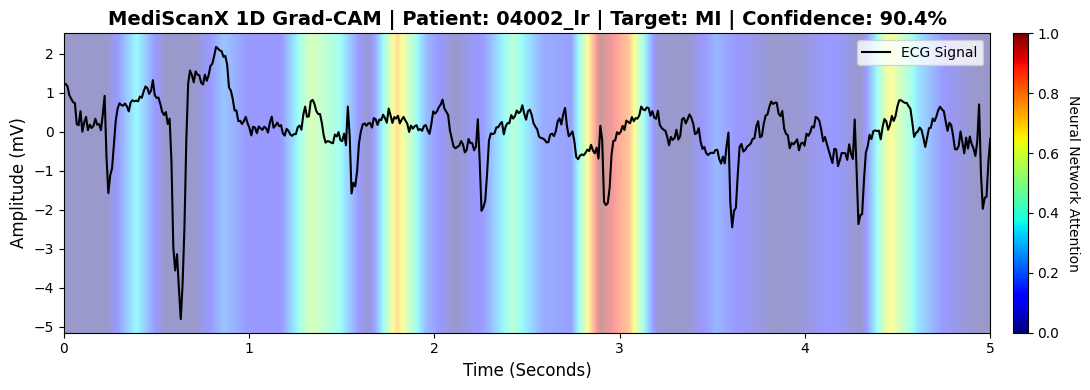

In [16]:
def load_model(cfg: ECGInferenceConfig) -> tuple[pl.LightningModule, nn.Module]:
    """Load the correct ECG model architecture based on checkpoint keys."""

    checkpoint = torch.load(cfg.checkpoint_path, map_location=cfg.device)
    state_dict = checkpoint["state_dict"] if "state_dict" in checkpoint else checkpoint

    if any(key.startswith("initial_conv") or key.startswith("res_block") for key in state_dict.keys()):
        model = LegacyGradCAMECGClassifier(cfg)
        target_layer = model.res_block2
        model_name = "legacy residual ECG architecture"
    else:
        model = MediScanXECGClassifier(cfg)
        target_layer = model.conv3
        model_name = "refactored CNN-BiLSTM ECG architecture"

    model.load_state_dict(state_dict, strict=True)
    model.to(cfg.device)
    model.eval()
    print(f"MediScanX ECG model loaded successfully using the {model_name}.")
    return model, target_layer


def main() -> None:
    """Entry point for the refactored ECG inference script."""

    cfg = ECGInferenceConfig()
    model, target_layer = load_model(cfg)
    preprocessor = ECGPreprocessor(cfg)
    gradcam = GradCAM1D(cfg, model, target_layer)
    engine = ECGInferenceEngine(cfg, model, preprocessor, gradcam)

    results = engine.run(cfg.sample_file_path, target_class_idx=1, lead_idx=1)
    engine.visualize(results)


main()